# Day 2 — Linear Regression

Training a LinearRegression model on the California housing dataset to predict median_house_value, interpreting its coefficients, and evaluating it against a baseline.

## Loading the Dataset and Initial Inspection
Load the housing dataset and review its shape, structure, and missing values before preparing it for modeling.

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
) 
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The dataset has 20,640 rows and 10 columns, covering housing block features such as location, age, room counts, population, income, and the target, median_house_value.

In [25]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


.info() shows total_bedrooms has fewer non-null entries than the rest — a first hint of missing data, confirmed below.

In [26]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

.isna().sum() confirms total_bedrooms is missing 207 out of 20,640 values, while every other column is complete.

In [27]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

The missing total_bedrooms values are filled with the column's mean, so no rows need to be dropped before modeling.

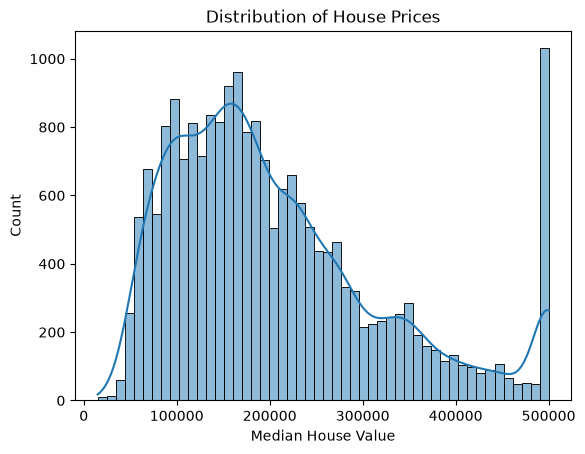

In [28]:
sns.histplot(data=df, x="median_house_value", bins=50, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

The histogram shows median_house_value is right-skewed, with a large spike at the top of the range — a sign the dataset was capped at a maximum house value (a common quirk of this dataset), which the model will effectively treat as a hard ceiling.

In [29]:
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)

ocean_proximity (a categorical column) is one-hot encoded into separate 0/1 columns, since LinearRegression needs numeric input for every feature.

## Step 1 — Training the Linear Regression Model
Separate the data into features (X) and target (y), perform an 80/20 train/test split, and fit a LinearRegression model on the training data.

In [30]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

X holds every column except median_house_value; y holds only the target column.

In [31]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

An 80/20 train/test split is performed with random_state=42 fixed for reproducibility.

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-26838.27,-25468.35, 1102.19,...,117198.49,-24063.23,-15495.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.257e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


The model is trained — it has now learned one coefficient per feature plus an intercept from the training data.

In [33]:
predictions = model.predict(X_test)

model.predict(X_test) generates a predicted median_house_value for every row in the held-out test set.

## Step 2 — Interpreting the Coefficients
Report the model's coefficients and identify which feature has the strongest effect on the predicted house value.

In [34]:
model.coef_

array([-2.68382734e+04, -2.54683520e+04,  1.10218508e+03, -6.02150567e+00,
        1.02789395e+02, -3.81729064e+01,  4.82527528e+01,  3.94739752e+04,
       -1.89265829e+04, -5.87132390e+04,  1.17198490e+05, -2.40632251e+04,
       -1.54954428e+04])

In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,longitude,-26838.273372
1,latitude,-25468.352050
2,housing_median_age,1102.185084
3,total_rooms,-6.021506
4,total_bedrooms,102.789395
5,population,-38.172906
6,households,48.252753
7,median_income,39473.975175
8,ocean_proximity_<1H OCEAN,-18926.582862
9,ocean_proximity_INLAND,-58713.239023


**Strongest effect:** ocean_proximity_ISLAND has by far the largest coefficient (+117,198), meaning being on an island is associated with a much higher predicted house value than any other single factor — but since very few blocks in the dataset are actually on an island, this estimate is based on very little data and should be treated cautiously rather than as a reliable general effect.

**Strongest effect among the well-represented, continuous features:** median_income (+39,474) — for every one-unit increase in median income (this dataset measures it in tens of thousands of dollars), the predicted house value rises by about $39,474, holding all other features constant. This matches real-world intuition and is the coefficient most worth trusting and acting on.

Other notable patterns: longitude and latitude both have large negative coefficients, reflecting how strongly location drives California housing prices; total_rooms and population have small negative coefficients, which is counter-intuitive on their own and likely reflects correlation with other features (e.g. more rooms often means more bedrooms and higher population, so their individual effects get partly absorbed elsewhere).

## Step 3 — Evaluating the Model
Evaluate the model's predictions on the test set with MAE, RMSE, and R².

In [36]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print(mae)

50701.77903133015


MAE ≈ 50,702 on average, the model's predictions are off by about $50,702 from the true house value.

In [37]:
rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print(rmse)

70031.41991955669


**RMSE ≈ $70,031** — noticeably higher than the MAE, which means the model is making some large errors that get penalized more heavily by RMSE than by MAE.

In [38]:
r2 = r2_score(
    y_test,
    predictions
)

print(r2)

0.62573518211597


**R² ≈ 0.626** — the model explains about 62.6% of the variance in house prices. That's a meaningful amount, but a substantial 37% is still unexplained by this simple linear model.

## Step 4 — Comparing Against a Baseline
Compute the RMSE of a naive baseline that predicts the mean training-set house value for every test row, and compare it to the model's RMSE.

In [39]:
baseline_prediction = y_train.mean()

The baseline prediction is simply the mean median_house_value from the training set, repeated for every test row — a model that has "learned" nothing about the features.

In [40]:
baseline = [baseline_prediction] * len(y_test)

The baseline prediction list has one entry per test row, all equal to the same mean value.

In [41]:
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline)
)

print(baseline_rmse)

114485.63543099792


Baseline RMSE ≈ 114,486, compared to the model's RMSE of ≈ 70,031. The linear regression model cuts the error by roughly 39% relative to the baseline — a clear, substantial improvement, confirming the model has learned a genuinely useful relationship between the features and house prices rather than just predicting the average every time.

## Step 5 — Interpretation of Results

**Does the model add value?** Yes. Its RMSE (70,031) is far lower than the baseline's (114,486), a roughly 39% reduction in error, and its R² of 0.626 shows it explains a solid majority of the variance in house prices. A model that could not beat the baseline would have learned nothing useful — this one clearly did.

**What drives the predictions?** median_income is the most trustworthy strong predictor: higher-income areas predict higher house values, which matches real-world expectations and is backed by a large, well-represented feature (income varies smoothly across almost all 20,640 blocks). Location (longitude/latitude) also plays a large role, consistent with how much geography drives California real estate prices. The ocean_proximity_ISLAND coefficient is the single largest number in the table, but it's built on very few island samples, so it's more a data-quality caveat than a reliable general insight.

**Where the model falls short:** MAE (50,702) being noticeably lower than RMSE (70,031) signals that a subset of predictions have large errors, which pulls RMSE up disproportionately. This lines up with the right-skewed, capped distribution of median_house_value seen in the histogram earlier — a plain linear model struggles to fit both the bulk of typical-priced homes and the small cluster of capped, very high-value homes at the same time. Roughly 37% of the variance in house prices remains unexplained (R² = 0.626), meaning other factors — or a more flexible, non-linear model — would likely be needed to close the gap further.

